##Centro Universitário FMU
Disciplina: Técnicas de Machine Learning
2026.1
*  Professor Luciano Tadeu Pereira
* email luciano.tadeu@fmu.br

## Pré-processamento de Dados para Machine Learning

---

### Estrutura do Notebook

| Aula | Tema | Conteúdo |
|------|------|----------|
| Aula 1 | Configuração & Dados | Instalação, carregamento e exploração inicial |
| Aula 2 | Qualidade dos Dados | Dados ausentes, outliers e duplicatas |
| Aula 3 | Normalização | Min-Max Scaling e Z-score |
| Aula 4 | Transformação | Codificação Categórica e PCA |
| Aula 5 | Desafios Práticos | Exercícios integradores |


---
# AULA 1 — Configuração do Ambiente e Carregamento de Dados

## Objetivo
Preparar o ambiente de trabalho, instalar as bibliotecas necessárias e aprender a carregar dados de múltiplas fontes.

## Bibliotecas que usaremos
- **pandas** — manipulação de dados tabulares
- **numpy** — operações numéricas
- **matplotlib / seaborn** — visualização de dados
- **scikit-learn** — algoritmos de ML e pré-processamento


In [ ]:
# ============================================================
# CÉLULA 1 — Instalação e importação de bibliotecas
# ============================================================
# Instalamos versões específicas para garantir reprodutibilidade.
# O "!" executa comandos do sistema operacional dentro do Colab.

!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais globais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
import sklearn; print(f"   sklearn  {sklearn.__version__}")


## Fontes de Dados

### Opção A — Upload manual (arquivo fornecido pelo professor)
Use o painel lateral do Colab ou execute a célula abaixo para fazer o upload.

### Opção B — Datasets públicos recomendados

| Dataset | Tema | Link |
|---------|------|------|
| UCI Adult Income | Classificação socioeconômica | https://archive.ics.uci.edu/ml/datasets/adult |
| Titanic | Sobrevivência de passageiros | https://www.kaggle.com/c/titanic |
| Iris | Classificação de flores | https://archive.ics.uci.edu/ml/datasets/iris |
| House Prices | Preços de imóveis | https://www.kaggle.com/c/house-prices-advanced-regression-techniques |
| Heart Disease | Diagnóstico médico | https://archive.ics.uci.edu/ml/datasets/heart+disease |


In [44]:
# ============================================================
# CÉLULA 2 — Carregamento de dados
# ============================================================

import pandas as pd
import os

# Identifica o arquivo carregado mais recentemente
excel_files = [f for f in os.listdir('/content') if f.endswith('.xlsx')]

if excel_files:
    latest_file = max(['/content/' + f for f in excel_files], key=os.path.getctime)

    # Usamos header=2 para pular as linhas de aviso e pegar os nomes reais das colunas
    df = pd.read_excel(latest_file, header=2)

    print(f"✅ Dataset '{latest_file.split('/')[-1]}' carregado com sucesso!")
    print(f"   Shape: {df.shape[0]} linhas & {df.shape[1]} colunas\n")

    display(df.head())

    print("\nColunas do DataFrame:")
    print(df.columns.tolist())

else:
    print("❌ Nenhum arquivo .xlsx encontrado. Por favor, faça o upload.")

✅ Dataset 'alunos_dados.xlsx' carregado com sucesso!
   Shape: 32 linhas & 11 colunas



,ID,Nome,Idade,Sexo,Cidade,Nota_Media,Horas_Estudo_Sem,Renda_Familiar_R$,Reprovações,Acesso_Internet,Empregado
0,1,Ana Silva,21.0,M,Porto Alegre,5.5,10,13066.0,0,Sim,Não
1,2,Bruno Costa,19.0,M,Rio de Janeiro,150.0,34,10863.0,0,Sim,Não
2,3,Carla Souza,NaN,F,Goiânia,5.7,2,13432.0,1,Não,Não
3,4,Diego Lima,26.0,M,Curitiba,9.7,23,2674.0,0,Não,Sim
4,5,Elena Santos,29.0,F,Goiânia,5.6,4,12955.0,3,Sim,Não



Colunas do DataFrame:
['ID', 'Nome', 'Idade', 'Sexo', 'Cidade', 'Nota_Media', 'Horas_Estudo_Sem', 'Renda_Familiar_R$', 'Reprovações', 'Acesso_Internet', 'Empregado']


In [45]:
# ============================================================
# CÉLULA 3 — Exploração inicial dos dados (EDA)
# ============================================================
# Antes de qualquer tratamento, precisamos entender o que temos.
# Esta etapa é chamada de EDA (Exploratory Data Analysis).

print("=" * 55)
print("📊 INFORMAÇÕES GERAIS DO DATASET")
print("=" * 55)

print("\n🔷 Tipos de dados por coluna:")
print(df.dtypes)

print("\n🔷 Estatísticas descritivas (colunas numéricas):")
df.describe().round(2)


📊 INFORMAÇÕES GERAIS DO DATASET

🔷 Tipos de dados por coluna:
ID                     int64
Nome                  object
Idade                float64
Sexo                  object
Cidade                object
Nota_Media           float64
Horas_Estudo_Sem       int64
Renda_Familiar_R$    float64
Reprovações            int64
Acesso_Internet       object
Empregado             object
dtype: object

🔷 Estatísticas descritivas (colunas numéricas):


,ID,Idade,Nota_Media,Horas_Estudo_Sem,Renda_Familiar_R$,Reprovações
count,32.00,30.00,30.00,32.00,31.00,32.00
mean,15.06,25.63,12.16,21.41,330176.94,2.19
std,8.73,7.26,26.09,12.17,1794648.11,1.69
min,1.00,3.00,4.70,2.00,1009.00,0.00
25%,7.75,20.25,5.70,9.75,3657.50,1.00
50%,14.50,25.00,7.40,21.00,7543.00,2.00
75%,22.25,30.75,9.28,31.00,12726.50,3.00
max,30.00,35.00,150.00,40.00,9999999.00,5.00


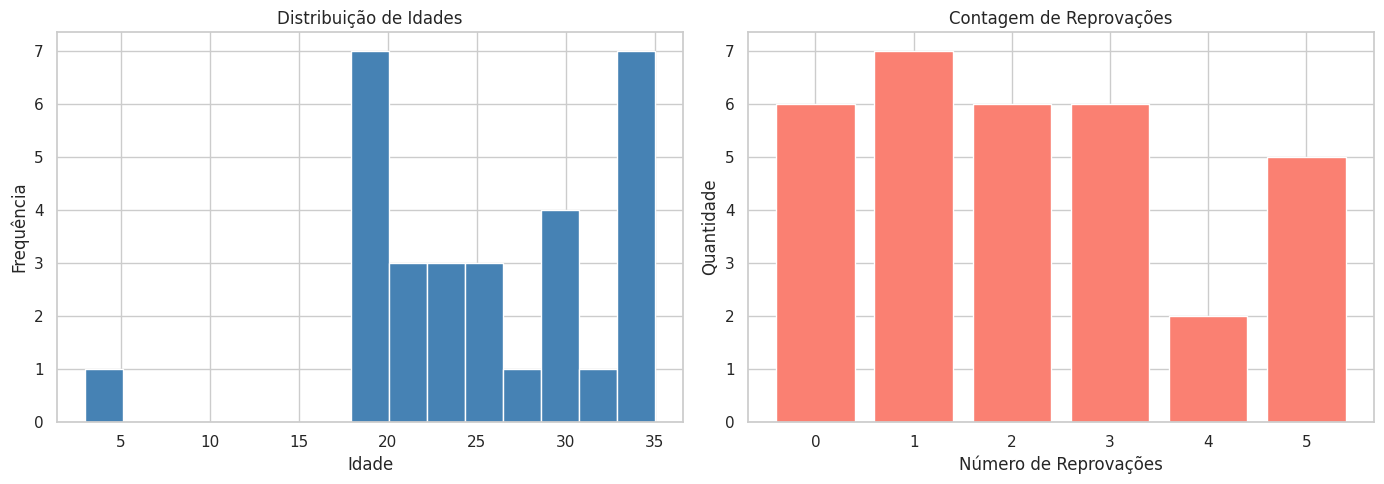

&#x1f4a1; Dica: O histograma mostra a concentração de idade dos alunos.


In [46]:
# ============================================================
# CÉLULA 4 — Visualização da distribuição dos dados
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma das idades (Ajustado para o nome da coluna no seu Excel)
axes[0].hist(df['Idade'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Idades')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

# Contagem de Reprovações (Substituindo 'Survived' que não existe neste dataset)
survival_counts = df['Reprovações'].value_counts().sort_index()
axes[1].bar(survival_counts.index.astype(str), survival_counts.values,
            color='salmon', edgecolor='white')
axes[1].set_title('Contagem de Reprovações')
axes[1].set_xlabel('Número de Reprovações')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

print("&#x1f4a1; Dica: O histograma mostra a concentração de idade dos alunos.")

In [33]:
# Vamos verificar como as colunas foram carregadas e ver o conteúdo das primeiras linhas
print("Nomes atuais das colunas:")
print(df.columns.tolist())

print("\nVisualização das primeiras 10 linhas do DataFrame bruto:")
display(df.head(10))

# DICA: Se a linha com os nomes (ID, Nome, Idade...) for a linha de índice 1,
# você deve recarregar o arquivo usando: pd.read_excel(arquivo, header=2)

Nomes atuais das colunas:
[2, 1, '1.1', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'female', 38, '1.2', 0, 'PC 17599', 712833, 'C85', 'C']

Visualização das primeiras 10 linhas do DataFrame bruto:


,2,1,1.1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1.2,0,PC 17599,712833,C85,C
0,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7925,NaN,S
1,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,531,C123,S
2,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,805,NaN,S
3,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,84583,NaN,Q
4,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,518625,E46,S
5,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21075,NaN,S
6,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,111333,NaN,S
7,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,300708,NaN,C
8,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,167,G6,S
9,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,2655,C103,S


---
# AULA 2 — Qualidade dos Dados: Ausentes, Outliers e Duplicatas

## Objetivo
Aprender a identificar e tratar os problemas mais comuns de qualidade de dados que afetam o desempenho dos modelos de Machine Learning.

## Por que isso é importante?
> *"Garbage in, garbage out"* — Se os dados de entrada são ruins, as previsões do modelo serão ruins também.

## Conceitos da aula
1. **Dados ausentes (Missing Values):** valores `NaN` ou vazios
2. **Outliers:** valores extremos que se desviam muito da maioria
3. **Duplicatas:** registros repetidos que inflacionam certos padrões


📊 Colunas com valores ausentes:

     Valores Ausentes  Percentual (%)
C85               686           77.17
38                177           19.91
C                   2            0.22


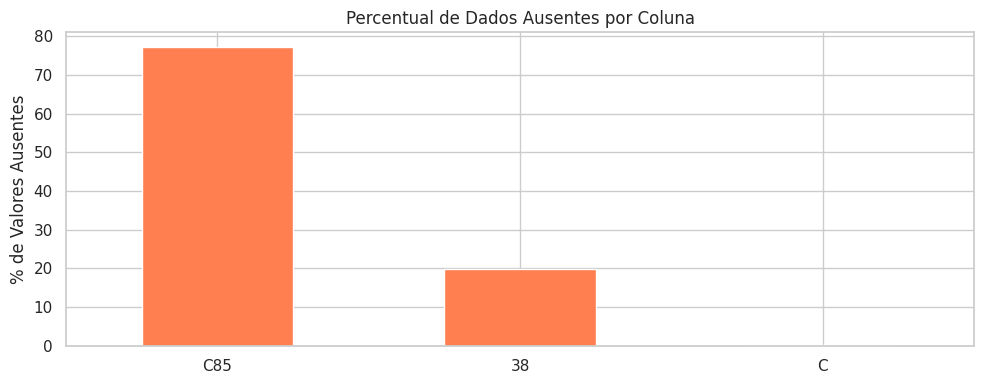

In [13]:
# ============================================================
# CÉLULA 5 — Identificação de dados ausentes
# ============================================================
# isnull() retorna True para cada célula com valor ausente.
# sum() conta quantos True existem por coluna.
# O resultado dividido pelo total de linhas dá o percentual.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    'Percentual (%)': missing_pct
}).query('`Valores Ausentes` > 0').sort_values('Percentual (%)', ascending=False)

print("📊 Colunas com valores ausentes:\n")
print(missing_df.to_string())

# Visualização
plt.figure(figsize=(10, 4))
missing_df['Percentual (%)'].plot(kind='bar', color='coral', edgecolor='white')
plt.title('Percentual de Dados Ausentes por Coluna')
plt.ylabel('% de Valores Ausentes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [48]:
# ============================================================
# CÉLULA 6 — Técnicas de imputação
# ============================================================
# Adaptado para as colunas: Idade, Nota_Media, etc.

df_tratado = df.copy()  # Sempre trabalhe com uma cópia!

# --- Estratégia 1: Imputação pela MEDIANA (Idade) ---
if 'Idade' in df_tratado.columns:
    mediana_idade = df_tratado['Idade'].median()
    df_tratado['Idade'] = df_tratado['Idade'].fillna(mediana_idade)
    print(f"✅ 'Idade': imputado pela mediana = {mediana_idade:.1f} anos")

# --- Estratégia 2: Imputação pela MEDIANA (Nota_Media) ---
if 'Nota_Media' in df_tratado.columns:
    # Nota_Media tinha 2 valores ausentes segundo a Célula 5
    mediana_nota = df_tratado['Nota_Media'].median()
    df_tratado['Nota_Media'] = df_tratado['Nota_Media'].fillna(mediana_nota)
    print(f"✅ 'Nota_Media': imputado pela mediana = {mediana_nota:.2f}")

# --- Estratégia 3: Imputação pela MODA (Cidade) ---
# Usamos para preencher possíveis vazios em colunas categóricas
if 'Cidade' in df_tratado.columns:
    moda_cidade = df_tratado['Cidade'].mode()[0]
    df_tratado['Cidade'] = df_tratado['Cidade'].fillna(moda_cidade)
    print(f"✅ 'Cidade': preenchido com a moda = '{moda_cidade}'")

# Verificação final
ausentes_restantes = df_tratado.isnull().sum().sum()
print(f"\n b📋 Valores ausentes restantes: {ausentes_restantes}")
display(df_tratado.head())

✅ 'Idade': imputado pela mediana = 25.0 anos
✅ 'Nota_Media': imputado pela mediana = 7.40
✅ 'Cidade': preenchido com a moda = 'Goiânia'

 b📋 Valores ausentes restantes: 1


,ID,Nome,Idade,Sexo,Cidade,Nota_Media,Horas_Estudo_Sem,Renda_Familiar_R$,Reprovações,Acesso_Internet,Empregado
0,1,Ana Silva,21.0,M,Porto Alegre,5.5,10,13066.0,0,Sim,Não
1,2,Bruno Costa,19.0,M,Rio de Janeiro,150.0,34,10863.0,0,Sim,Não
2,3,Carla Souza,25.0,F,Goiânia,5.7,2,13432.0,1,Não,Não
3,4,Diego Lima,26.0,M,Curitiba,9.7,23,2674.0,0,Não,Sim
4,5,Elena Santos,29.0,F,Goiânia,5.6,4,12955.0,3,Sim,Não


📌 Análise de Outliers — coluna 'Nota_Media'
   Q1 = 5.70 | Q3 = 9.22 | IQR = 3.52
   Limites: [0.41, 14.51]
   Outliers encontrados (IQR): 1 (3.1%)


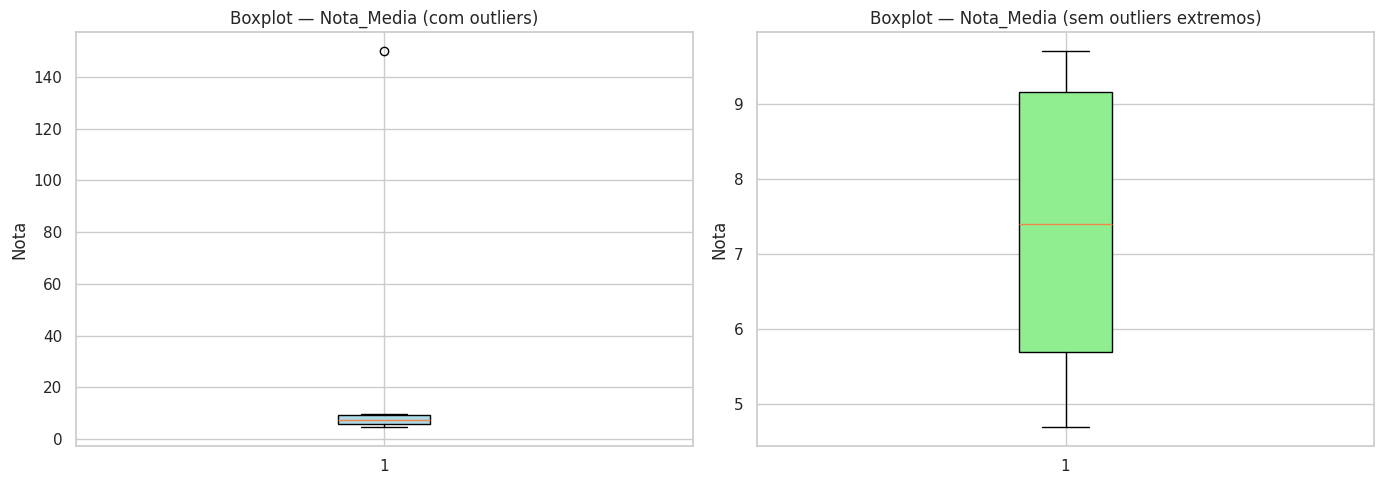

💡 Nota: A remoção de outliers depende do contexto do negócio!


In [49]:
# ============================================================
# CÉLULA 7 — Detecção de outliers com IQR e Z-score
# ============================================================
# MÉTODO 1: IQR (Intervalo Interquartil)
# Outliers são valores abaixo de Q1-1.5*IQR ou acima de Q3+1.5*IQR

coluna = 'Nota_Media'  # Alterado de 'Fare' para uma coluna do seu dataset

Q1 = df_tratado[coluna].quantile(0.25)
Q3 = df_tratado[coluna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df_tratado[(df_tratado[coluna] < limite_inferior) |
                           (df_tratado[coluna] > limite_superior)]

print(f"📌 Análise de Outliers — coluna '{coluna}'")
print(f"   Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}")
print(f"   Limites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"   Outliers encontrados (IQR): {len(outliers_iqr)} ({len(outliers_iqr)/len(df_tratado)*100:.1f}%)")

# Visualização: Boxplot revela outliers visivelmente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_tratado[coluna].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title(f'Boxplot — {coluna} (com outliers)')
axes[0].set_ylabel('Nota')

# Sem outliers para comparar
df_sem_outliers = df_tratado[(df_tratado[coluna] >= limite_inferior) & (df_tratado[coluna] <= limite_superior)]
axes[1].boxplot(df_sem_outliers[coluna].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title(f'Boxplot — {coluna} (sem outliers extremos)')
axes[1].set_ylabel('Nota')

plt.tight_layout()
plt.show()
print("💡 Nota: A remoção de outliers depende do contexto do negócio!")

In [35]:
# ============================================================
# CÉLULA 8 — Remoção de duplicatas
# ============================================================
# Registros duplicados podem fazer com que certos padrões
# tenham uma influência artificialmente maior no modelo.

print(f"📋 Linhas ANTES da remoção: {len(df_tratado)}")

n_duplicatas = df_tratado.duplicated().sum()
print(f"   Duplicatas encontradas: {n_duplicatas}")

df_tratado = df_tratado.drop_duplicates()
print(f"📋 Linhas APÓS a remoção:  {len(df_tratado)}")

# ⚠️ Desafio para o aluno (ver Aula 5)
print("\n🏆 DESAFIO: O que acontece se você buscar duplicatas apenas nas colunas")
print("   ['Name', 'Age', 'Sex']? Experimente com df.duplicated(subset=[...])")


📋 Linhas ANTES da remoção: 889
   Duplicatas encontradas: 0
📋 Linhas APÓS a remoção:  889

🏆 DESAFIO: O que acontece se você buscar duplicatas apenas nas colunas
   ['Name', 'Age', 'Sex']? Experimente com df.duplicated(subset=[...])


---
# AULA 3 — Normalização de Dados

## Objetivo
Compreender por que e como normalizar dados numéricos, e qual técnica é mais adequada para cada situação.

## Por que normalizar?
Algoritmos como KNN, SVM e Redes Neurais calculam distâncias entre pontos.  
Se uma feature tem valores de 0–1 e outra de 0–100.000, a segunda domina o cálculo injustamente.

## Técnicas abordadas
| Técnica | Fórmula | Quando usar |
|---------|---------|-------------|
| **Min-Max Scaling** | `(x - min) / (max - min)` | Quando não há outliers severos |
| **Z-score** | `(x - média) / desvio_padrão` | Quando os dados seguem distribuição normal |


📊 Comparação ANTES vs DEPOIS do Min-Max Scaling:

           Coluna  Min Original  Max Original  Min Scaled  Max Scaled
            Idade           3.0          35.0         0.0         1.0
       Nota_Media           4.7         150.0         0.0         1.0
 Horas_Estudo_Sem           2.0          40.0         0.0         1.0
Renda_Familiar_R$        1009.0     9999999.0         0.0         1.0


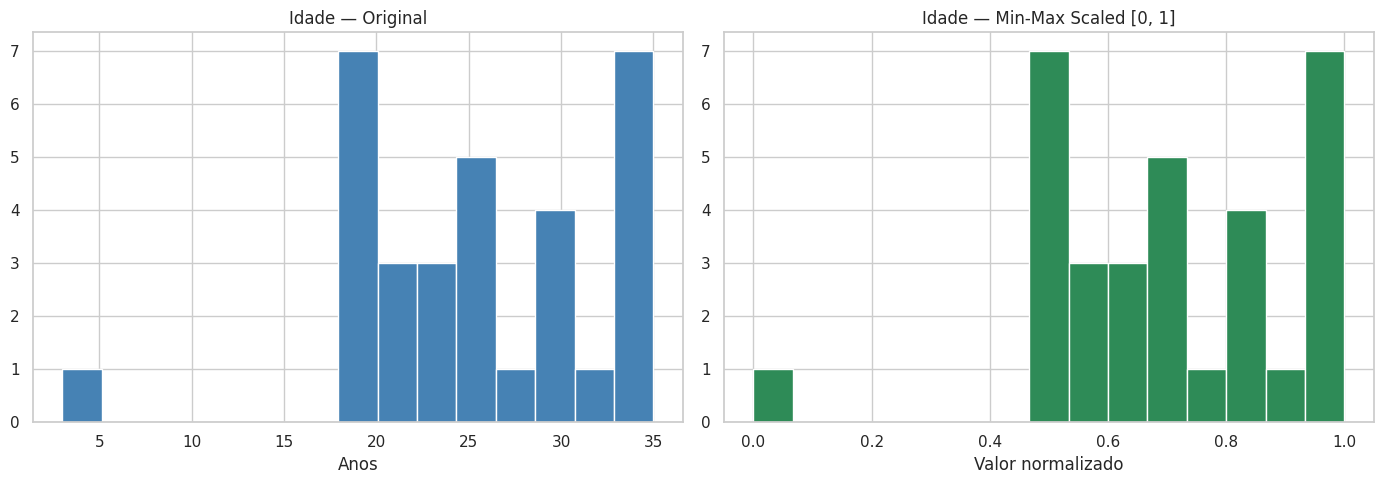

💡 Observe que a FORMA da distribuição não muda — apenas a escala!


In [50]:
# ============================================================
# CÉLULA 9 — Min-Max Scaling (CORRIGIDA PARA ALUNOS)
# ============================================================
# O MinMaxScaler transforma todos os valores para o intervalo [0, 1].

# Definimos as colunas numéricas presentes no seu dataset
colunas_numericas = ['Idade', 'Nota_Media', 'Horas_Estudo_Sem', 'Renda_Familiar_R$']

scaler_minmax = MinMaxScaler()

# fit_transform: aprende os parâmetros (min, max) E transforma os dados
df_minmax = df_tratado.copy()
df_minmax[colunas_numericas] = scaler_minmax.fit_transform(df_tratado[colunas_numericas])

print("📊 Comparação ANTES vs DEPOIS do Min-Max Scaling:\n")
comparacao = pd.DataFrame({
    'Coluna': colunas_numericas,
    'Min Original': df_tratado[colunas_numericas].min().values.round(2),
    'Max Original': df_tratado[colunas_numericas].max().values.round(2),
    'Min Scaled': df_minmax[colunas_numericas].min().values.round(4),
    'Max Scaled': df_minmax[colunas_numericas].max().values.round(4),
})
print(comparacao.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_tratado['Idade'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Idade — Original')
axes[0].set_xlabel('Anos')

axes[1].hist(df_minmax['Idade'], bins=15, color='seagreen', edgecolor='white')
axes[1].set_title('Idade — Min-Max Scaled [0, 1]')
axes[1].set_xlabel('Valor normalizado')

plt.tight_layout()
plt.show()
print("💡 Observe que a FORMA da distribuição não muda — apenas a escala!")

📊 Estatísticas após Z-score (esperado: média≈0, std≈1):

               Idade  Nota_Media  Horas_Estudo_Sem  Renda_Familiar_R$
Média          0.000      -0.000            -0.000             0.0000
Desvio Padrão  1.016       1.016             1.016             1.0165


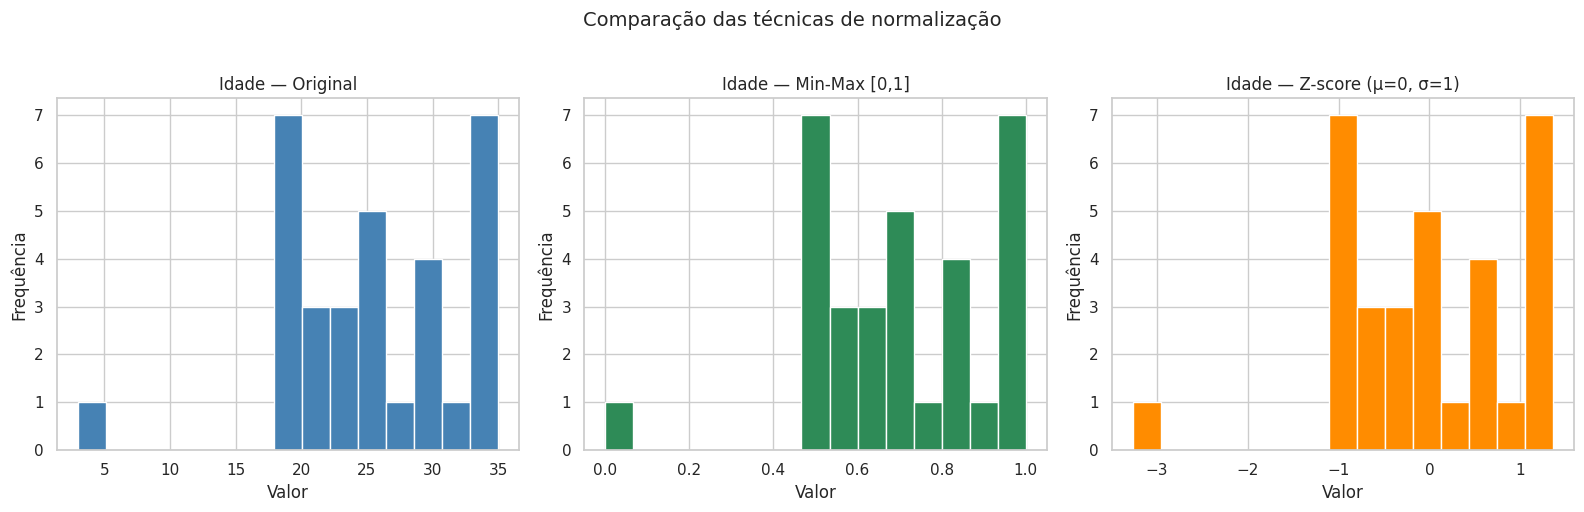

In [51]:
# ============================================================
# CÉLULA 10 — Z-score Normalization (StandardScaler)
# ============================================================
# O StandardScaler transforma os dados para média=0 e desvio_padrão=1.
# Fórmula: z = (x - μ) / σ
# Valores positivos: acima da média | Negativos: abaixo da média

scaler_zscore = StandardScaler()
df_zscore = df_tratado.copy()
df_zscore[colunas_numericas] = scaler_zscore.fit_transform(df_tratado[colunas_numericas])

print("📊 Estatísticas após Z-score (esperado: média≈0, std≈1):\n")
stats = df_zscore[colunas_numericas].agg(['mean', 'std']).round(4)
stats.index = ['Média', 'Desvio Padrão']
print(stats.to_string())

# Comparação visual das três versões da coluna 'Idade'
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ajustado para usar 'Idade' em vez de 'Age'
for ax, data, title, color in zip(
    axes,
    [df_tratado['Idade'], df_minmax['Idade'], df_zscore['Idade']],
    ['Original', 'Min-Max [0,1]', 'Z-score (μ=0, σ=1)'],
    ['steelblue', 'seagreen', 'darkorange']
):
    ax.hist(data.dropna(), bins=15, color=color, edgecolor='white')
    ax.set_title(f'Idade — {title}')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.suptitle('Comparação das técnicas de normalização', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# AULA 4 — Transformação e Redução de Dimensionalidade

## Objetivo
Aprender a codificar variáveis categóricas para uso em modelos numéricos e aplicar PCA para reduzir o número de features.

## Conceitos da aula
1. **Label Encoding** — converte categorias em números inteiros (ex: Gato→0, Cão→1)
2. **One-Hot Encoding** — cria colunas binárias para cada categoria
3. **PCA** — Análise de Componentes Principais para redução de dimensionalidade

## Quando usar cada codificação?
| Técnica | Use quando... | Cuidado com... |
|---------|--------------|----------------|
| Label Encoding | Variável ordinal (P, M, G) | Não usar em nominais — cria ordem falsa |
| One-Hot Encoding | Variável nominal (cores, cidades) | Muitas categorias = curse of dimensionality |


In [52]:
# ============================================================
# CÉLULA 11 — Codificação Categórica
# ============================================================

df_encoded = df_tratado.copy()

# --- Label Encoding: 'Sexo' é binário (M/F) ---
# Converte categorias em 0 e 1
le = LabelEncoder()
df_encoded['Sexo_encoded'] = le.fit_transform(df_encoded['Sexo'])
print("🔷 Label Encoding — 'Sexo':")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# --- One-Hot Encoding: 'Cidade' tem múltiplas categorias ---
# Criamos colunas binárias para cada cidade
# drop_first=True evita a armadilha da variável dummy
df_encoded = pd.get_dummies(df_encoded, columns=['Cidade'],
                              prefix='Cidade', drop_first=True)

print("\n🔷 One-Hot Encoding — 'Cidade':")
colunas_cidade = [c for c in df_encoded.columns if c.startswith('Cidade_')]
print(f"   Algumas colunas criadas: {colunas_cidade[:5]}")

# Visualização do resultado
print("\nExemplo das transformações (primeiras 5 linhas):")
display(df_encoded[['Sexo', 'Sexo_encoded'] + colunas_cidade].head())

🔷 Label Encoding — 'Sexo':
{'F': np.int64(0), 'M': np.int64(1)}

🔷 One-Hot Encoding — 'Cidade':
   Algumas colunas criadas: ['Cidade_Curitiba', 'Cidade_Fortaleza', 'Cidade_Goiânia', 'Cidade_Manaus', 'Cidade_Porto Alegre']

Exemplo das transformações (primeiras 5 linhas):


,Sexo,Sexo_encoded,Cidade_Curitiba,Cidade_Fortaleza,Cidade_Goiânia,Cidade_Manaus,Cidade_Porto Alegre,Cidade_Recife,Cidade_Rio de Janeiro,Cidade_Salvador,Cidade_São Paulo
0,M,1,False,False,False,False,True,False,False,False,False
1,M,1,False,False,False,False,False,False,True,False,False
2,F,0,False,False,True,False,False,False,False,False,False
3,M,1,True,False,False,False,False,False,False,False,False
4,F,0,False,False,True,False,False,False,False,False,False


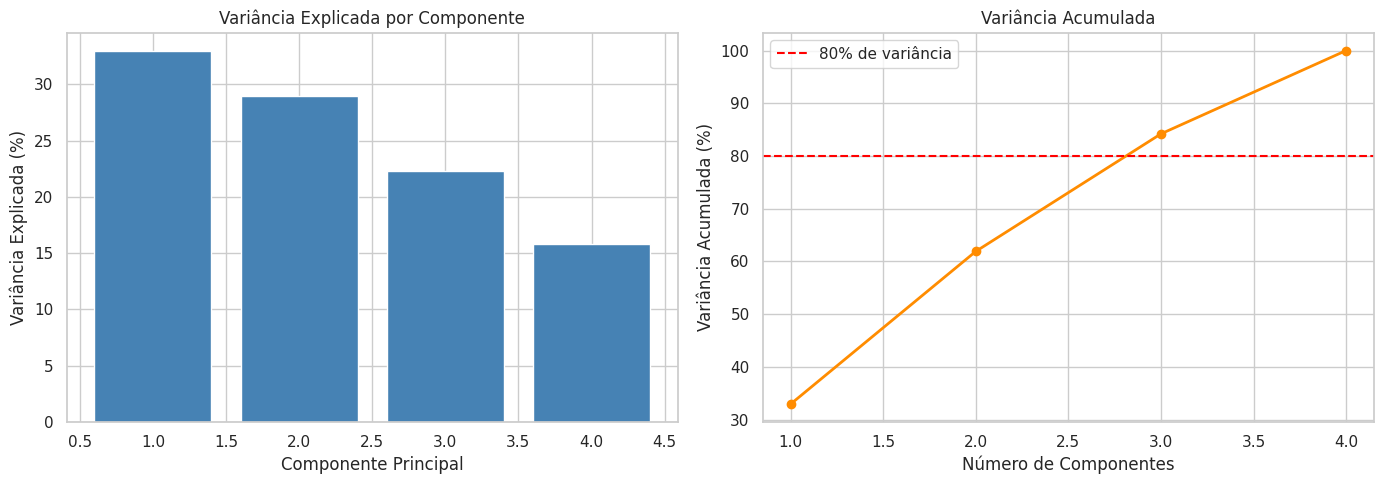

📊 Variância explicada por componente:
   CP1: 32.9%  |  Acumulado: 32.9%
   CP2: 29.0%  |  Acumulado: 61.9%
   CP3: 22.3%  |  Acumulado: 84.2%
   CP4: 15.8%  |  Acumulado: 100.0%


In [53]:
# ============================================================
# CÉLULA 12 — PCA (Análise de Componentes Principais)
# ============================================================
# PCA encontra as direções de maior variância nos dados e projeta
# os pontos nessas direções — reduzindo dimensões com mínima perda.
#
# ⚠️ IMPORTANTE: sempre normalize os dados ANTES de aplicar PCA!

# Preparar features numéricas para PCA (Usando as colunas dos seus alunos)
features_pca = ['Idade', 'Nota_Media', 'Horas_Estudo_Sem', 'Renda_Familiar_R$']
X_pca = df_tratado[features_pca].dropna()

# Normalizar primeiro
X_scaled = StandardScaler().fit_transform(X_pca)

# Aplicar PCA sem definir n_components para ver a variância explicada
pca_full = PCA()
pca_full.fit(X_scaled)

variancia_explicada = pca_full.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

# Gráfico do cotovelo (Scree Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(variancia_explicada)+1), variancia_explicada * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Variância Explicada por Componente')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Variância Explicada (%)')

axes[1].plot(range(1, len(variancia_acumulada)+1), variancia_acumulada * 100,
             'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% de variância')
axes[1].set_title('Variância Acumulada')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Variância Acumulada (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("📊 Variância explicada por componente:")
for i, v in enumerate(variancia_explicada, 1):
    print(f"   CP{i}: {v*100:.1f}%  |  Acumulado: {variancia_acumulada[i-1]*100:.1f}%")

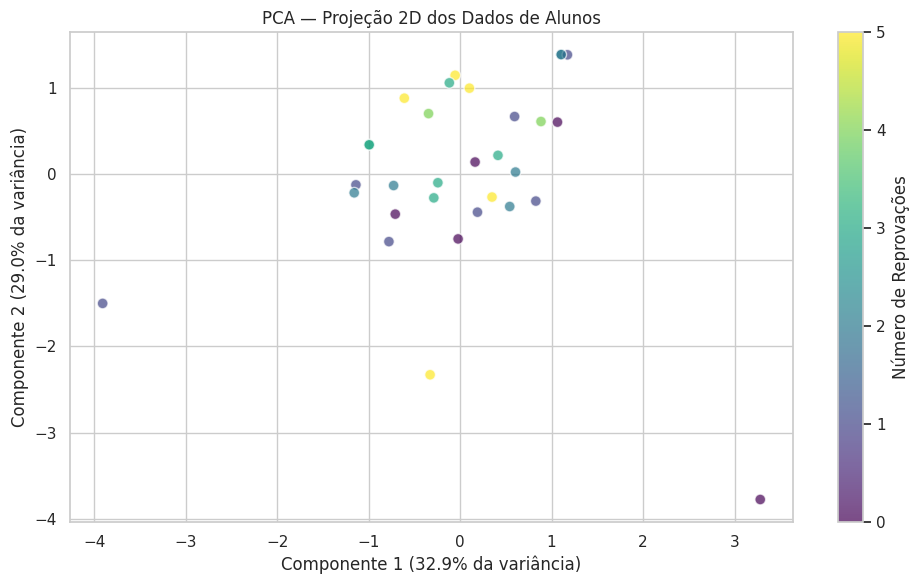

✅ Redução: 4 features → 2 componentes
   Variância preservada: 61.9%
💡 As cores representam o número de reprovações de cada aluno.


In [54]:
# ============================================================
# CÉLULA 13 — Redução para 2 componentes e visualização
# ============================================================

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Associar com uma coluna de interesse do seu dataset (ex: Reprovações)
y_target = df_tratado.loc[X_pca.index, 'Reprovações']

plt.figure(figsize=(10, 6))
# Criamos um scatter plot colorido pelo número de reprovações
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
            c=y_target, cmap='viridis', alpha=0.7, s=60, edgecolor='white')

plt.title('PCA — Projeção 2D dos Dados de Alunos')
plt.xlabel(f'Componente 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância)')

# Adicionar barra de cores para representar as reprovações
cbar = plt.colorbar(scatter)
cbar.set_label('Número de Reprovações')

plt.tight_layout()
plt.show()

print(f"✅ Redução: {len(features_pca)} features → 2 componentes")
print(f"   Variância preservada: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print("💡 As cores representam o número de reprovações de cada aluno.")

---
# AULA 5 — Desafios Práticos e Pipeline Completo

## Objetivo
Consolidar todos os conhecimentos anteriores em exercícios práticos e construir um pipeline de pré-processamento reutilizável.

## Desafios

> **Nível 1 — Iniciante**  
> **Nível 2 — Intermediário**  
> **Nível 3 — Avançado**


In [55]:
# ============================================================
# CÉLULA 14 — Pipeline completo de pré-processamento
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Definir colunas por tipo baseando-se no seu dataset de ALUNOS
colunas_num = ['Idade', 'Nota_Media', 'Horas_Estudo_Sem', 'Renda_Familiar_R$']
colunas_cat = ['Sexo', 'Cidade', 'Acesso_Internet', 'Empregado']

# 2. Pipeline numérico: preencher vazios com mediana + normalizar (Z-score)
pipeline_num = Pipeline([
    ('imputacao', SimpleImputer(strategy='median')),
    ('normalizacao', StandardScaler())
])

# 3. Pipeline categórico: preencher vazios com o mais comum + transformar em números (One-Hot)
pipeline_cat = Pipeline([
    ('imputacao', SimpleImputer(strategy='most_frequent')),
    ('codificacao', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Combinar os dois processos em um transformador de colunas
preprocessor = ColumnTransformer([
    ('num', pipeline_num, colunas_num),
    ('cat', pipeline_cat, colunas_cat)
])

# 5. Aplicar nos dados originais
# (Usando df_original que definimos anteriormente para testar o fluxo do zero)
X = df[colunas_num + colunas_cat]

X_processado = preprocessor.fit_transform(X)

print("✅ Pipeline executado com sucesso!")
print(f"   Shape de entrada (original): {X.shape}")
print(f"   Shape de saída (processado): {X_processado.shape}")
print("\n🔍 O pipeline agora transformou todas as suas colunas em números padronizados!")

✅ Pipeline executado com sucesso!
   Shape de entrada (original): (32, 8)
   Shape de saída (processado): (32, 20)

🔍 O pipeline agora transformou todas as suas colunas em números padronizados!


## Desafios para Praticar

Complete os desafios abaixo. As respostas estão nas células ocultas — tente resolver sozinho antes de revelar!


---
# Resumo das Aulas

## O que aprendemos

### Aula 1 — Fundamentos
- Configuração do ambiente Colab
- Carregamento de dados (upload + fontes públicas)
- Exploração inicial com EDA

### Aula 2 — Qualidade dos Dados
- **Dados ausentes:** imputação por mediana, moda ou remoção
- **Outliers:** detecção por IQR e Z-score
- **Duplicatas:** identificação e remoção

### Aula 3 — Normalização
- **Min-Max Scaling:** intervalo [0,1], sensível a outliers
- **Z-score:** média=0, desvio=1, robusto para distribuições normais

### Aula 4 — Transformação
- **Label Encoding:** para variáveis binárias/ordinais
- **One-Hot Encoding:** para variáveis nominais
- **PCA:** redução de dimensionalidade com mínima perda de informação

### Aula 5 — Pipeline
- Automatização do fluxo de pré-processamento
- Boas práticas com `sklearn.pipeline.Pipeline`

---

## Referências e Leitura Complementar
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, 3ª ed.
- McKinney, W. (2022). *Python for Data Analysis*, 3ª ed.
- Documentação scikit-learn: https://scikit-learn.org/stable/
- UCI Machine Learning Repository: https://archive.ics.uci.edu/
- Kaggle Datasets: https://www.kaggle.com/datasets
